<a href="https://colab.research.google.com/github/ricomelgozajjesus/monografia-armonica/blob/main/python-lab/notebooks/Notebook_VII_03_reticula_espectral_floquet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook VII.3 — Retícula espectral de Floquet

<a href="https://colab.research.google.com/github/ricomelgozajjesus/monografia-armonica/blob/main/python-lab/notebooks/Notebook_VII_03_reticula_espectral_floquet.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open in Colab"/>
</a>

Este notebook acompaña la **Ventana Computacional VII.3: Retícula espectral de Floquet**.

La idea central es visualizar que cada exponente de Floquet \(\rho_i\) no aparece como un punto aislado, sino como una familia armónica

\[
\rho_{i,k}=\rho_i+jk\omega,\qquad k\in\mathbb{Z},
\]

donde \(\omega=2\pi/T\) es la frecuencia base del sistema periódico.


## 1. Sistema periódico de prueba

Usaremos nuevamente un oscilador lineal con rigidez periódica:

\[
\ddot q + \left(\omega_0^2+\epsilon\cos(\Omega t)\right)q=0.
\]

En forma de estado:

\[
x=
\begin{bmatrix}
q\\
\dot q
\end{bmatrix},
\qquad
\dot x=A(t)x,
\]

con

\[
A(t)=
\begin{bmatrix}
0 & 1\\
-\omega_0^2-\epsilon\cos(\Omega t) & 0
\end{bmatrix}.
\]

La matriz \(A(t)\) es periódica de período

\[
T=\frac{2\pi}{\Omega}.
\]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.linalg import eig

np.set_printoptions(precision=6, suppress=True)


## 2. Parámetros

Primero usaremos un caso moderado, donde la modulación periódica es visible pero no buscamos forzar una inestabilidad paramétrica fuerte.


In [6]:
import numpy as np

omega0 = 1.0
Omega = 1.0
epsilon = 0.35

T = 2*np.pi/Omega
omega = 2*np.pi/T

print(f"omega0  = {omega0}")
print(f"Omega   = {Omega}")
print(f"epsilon = {epsilon}")
print(f"T       = {T:.6f}")
print(f"omega   = {omega:.6f}")

omega0  = 1.0
Omega   = 1.0
epsilon = 0.35
T       = 6.283185
omega   = 1.000000


## 3. Matriz periódica e integración de la matriz fundamental

La matriz fundamental satisface

\[
\dot\Phi(t)=A(t)\Phi(t),\qquad \Phi(0)=I.
\]

Al integrar esta ecuación desde \(0\) hasta \(T\), obtenemos la matriz de monodromía:

\[
M=\Phi(T).
\]


In [7]:
import numpy as np
from scipy.integrate import solve_ivp

def A(t, omega0, Omega, epsilon):
    return np.array([
        [0.0, 1.0],
        [-(omega0**2 + epsilon*np.cos(Omega*t)), 0.0]
    ])

def phi_rhs(t, y, omega0_val, Omega_val, epsilon_val):
    Phi = y.reshape((2, 2))
    At = np.array([
        [0.0, 1.0],
        [-(omega0_val**2 + epsilon_val*np.cos(Omega_val*t)), 0.0]
    ])
    dPhi = At @ Phi
    return dPhi.reshape(4)

Phi0 = np.eye(2).reshape(4)

sol_T = solve_ivp(
    phi_rhs,
    (0.0, T),
    Phi0,
    args=(omega0, Omega, epsilon),
    t_eval=[T],
    rtol=1e-11,
    atol=1e-13
)

M = sol_T.y[:, -1].reshape((2, 2))

print("M = Phi(T)")
print(M)
print("\ndet(M) =", np.linalg.det(M))

M = Phi(T)
[[1.00256516 0.02548947]
 [0.20153021 1.00256516]]

det(M) = 0.9999999999867571


## 4. Multiplicadores y exponentes de Floquet

Los valores propios de \(M\) son los multiplicadores de Floquet:

\[
\mu_i=\lambda_i(M).
\]

Una rama principal de los exponentes se obtiene como

\[
\rho_i=\frac{1}{T}\log(\mu_i).
\]

Debido a que el logaritmo complejo es multivaluado, también existen las ramas

\[
\rho_{i,k}=\rho_i+jk\omega.
\]


In [10]:
from scipy.linalg import eig

multipliers, eigenvectors = eig(M)
rho = np.log(multipliers)/T

print("Floquet multipliers:")
for i, mu in enumerate(multipliers, start=1):
    print(f"mu_{i} = {mu:.8f}, |mu_{i}| = {abs(mu):.8f}")

print("\nPrincipal Floquet exponents:")
for i, r in enumerate(rho, start=1):
    print(f"rho_{i} = {r:.8f}   Re={r.real:.8f}, Im={r.imag:.8f}")

Floquet multipliers:
mu_1 = 0.93089301+0.00000000j, |mu_1| = 0.93089301
mu_2 = 1.07423731+0.00000000j, |mu_2| = 1.07423731

Principal Floquet exponents:
rho_1 = -0.01139723+0.00000000j   Re=-0.01139723, Im=0.00000000
rho_2 = 0.01139723+0.00000000j   Re=0.01139723, Im=0.00000000


## 5. Construcción de la retícula espectral

Construimos un conjunto finito de réplicas armónicas:

\[
\rho_{i,k}=\rho_i+jk\omega,\qquad k=-K,\ldots,K.
\]

Cada exponente base genera una columna vertical de puntos en el plano complejo. La separación vertical entre dos réplicas consecutivas es \(\omega\).


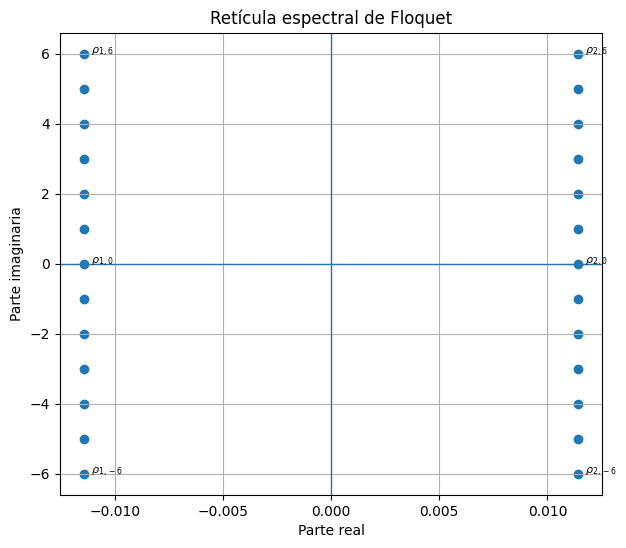

In [13]:
import matplotlib.pyplot as plt

K = 6

lattice = []
labels = []

for i, r in enumerate(rho, start=1):
    for k in range(-K, K+1):
        point = r + 1j*k*omega
        lattice.append(point)
        labels.append((i, k))

lattice = np.array(lattice)

plt.figure(figsize=(7, 6))
plt.scatter(lattice.real, lattice.imag)

for point, (i, k) in zip(lattice, labels):
    if k in [-K, 0, K]:
        plt.text(point.real, point.imag, rf"  $\rho_{{{i},{k}}}$", fontsize=8)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.xlabel("Parte real")
plt.ylabel("Parte imaginaria")
plt.title("Retícula espectral de Floquet")
plt.grid(True)
plt.show()

## 6. Verificación de la separación armónica

Para una misma familia \(i\),

\[
\rho_{i,k+1}-\rho_{i,k}=j\omega.
\]

Verificamos numéricamente esta separación.


In [14]:
print(f"omega = {omega:.8f}\n")

for i, r in enumerate(rho, start=1):
    print(f"Family i = {i}")
    for k in range(-2, 2):
        rho_k = r + 1j*k*omega
        rho_k1 = r + 1j*(k+1)*omega
        diff = rho_k1 - rho_k
        print(f"  k={k:2d} -> k+1={k+1:2d}: diff = {diff:.8f}, |imag diff| = {abs(diff.imag):.8f}")
    print()

omega = 1.00000000

Family i = 1
  k=-2 -> k+1=-1: diff = 0.00000000+1.00000000j, |imag diff| = 1.00000000
  k=-1 -> k+1= 0: diff = 0.00000000+1.00000000j, |imag diff| = 1.00000000
  k= 0 -> k+1= 1: diff = 0.00000000+1.00000000j, |imag diff| = 1.00000000
  k= 1 -> k+1= 2: diff = 0.00000000+1.00000000j, |imag diff| = 1.00000000

Family i = 2
  k=-2 -> k+1=-1: diff = 0.00000000+1.00000000j, |imag diff| = 1.00000000
  k=-1 -> k+1= 0: diff = 0.00000000+1.00000000j, |imag diff| = 1.00000000
  k= 0 -> k+1= 1: diff = 0.00000000+1.00000000j, |imag diff| = 1.00000000
  k= 1 -> k+1= 2: diff = 0.00000000+1.00000000j, |imag diff| = 1.00000000



## 7. Comparación de casos: modulación moderada y modulación más intensa

Ahora encapsulamos el cálculo en una función para comparar dos valores de \(\epsilon\). Esto permite observar cómo cambia la posición de los exponentes base y, por lo tanto, de toda la retícula.


In [15]:
def floquet_lattice_for_epsilon(epsilon_value, K=6, omega0=1.0, Omega=1.0):
    T_local = 2*np.pi/Omega
    omega_local = 2*np.pi/T_local

    def rhs(t, y):
        Phi = y.reshape((2, 2))
        At = np.array([
            [0.0, 1.0],
            [-(omega0**2 + epsilon_value*np.cos(Omega*t)), 0.0]
        ])
        return (At @ Phi).reshape(4)

    sol = solve_ivp(
        rhs,
        (0.0, T_local),
        np.eye(2).reshape(4),
        t_eval=[T_local],
        rtol=1e-11,
        atol=1e-13
    )

    M_local = sol.y[:, -1].reshape((2, 2))
    mu_local, _ = eig(M_local)
    rho_local = np.log(mu_local)/T_local

    lattice_local = []
    family_local = []
    for i, r in enumerate(rho_local, start=1):
        for k in range(-K, K+1):
            lattice_local.append(r + 1j*k*omega_local)
            family_local.append(i)

    return {
        "epsilon": epsilon_value,
        "T": T_local,
        "omega": omega_local,
        "M": M_local,
        "multipliers": mu_local,
        "rho": rho_local,
        "lattice": np.array(lattice_local),
        "family": np.array(family_local)
    }

case1 = floquet_lattice_for_epsilon(0.35, K=6)
case2 = floquet_lattice_for_epsilon(1.20, K=6)

for case in [case1, case2]:
    print(f"epsilon = {case['epsilon']}")
    print("multipliers:", case["multipliers"])
    print("rho:", case["rho"])
    print("max |mu|:", max(abs(case["multipliers"])))
    print()

epsilon = 0.35
multipliers: [0.93089301+0.j 1.07423731+0.j]
rho: [-0.01139723+0.j  0.01139723+0.j]
max |mu|: 1.0742373112227606

epsilon = 1.2
multipliers: [2.24548975+0.j 0.44533715+0.j]
rho: [ 0.1287442+0.j -0.1287442+0.j]
max |mu|: 2.245489754314854



## 8. Gráfica comparativa de retículas

La siguiente gráfica compara las retículas para dos valores de modulación. El desplazamiento horizontal indica cambio en la tasa efectiva de crecimiento/decaimiento. El desplazamiento vertical sigue gobernado por la frecuencia base.


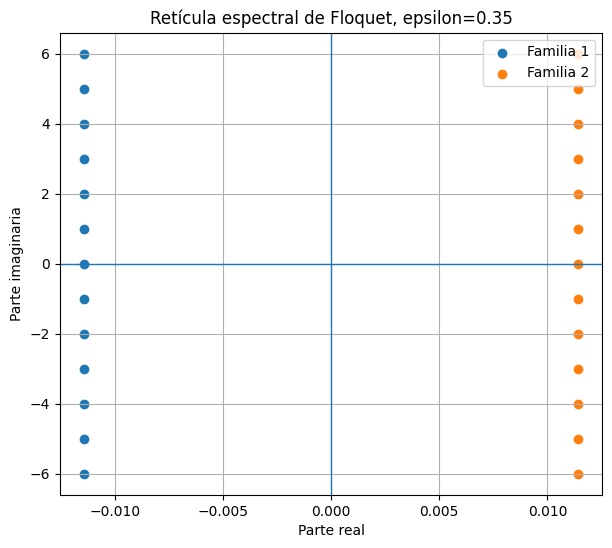

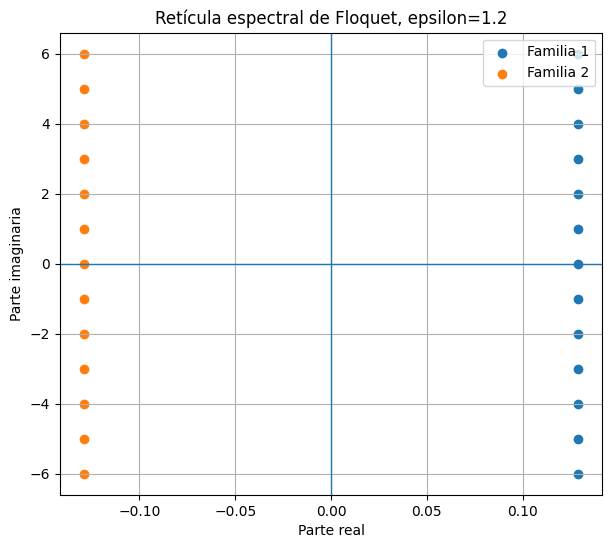

In [16]:
for case in [case1, case2]:
    plt.figure(figsize=(7, 6))
    lattice_local = case["lattice"]
    family_local = case["family"]

    for fam in sorted(set(family_local)):
        pts = lattice_local[family_local == fam]
        plt.scatter(pts.real, pts.imag, label=f"Familia {fam}")

    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlabel("Parte real")
    plt.ylabel("Parte imaginaria")
    plt.title(f"Retícula espectral de Floquet, epsilon={case['epsilon']}")
    plt.legend()
    plt.grid(True)
    plt.show()

## 9. Lectura conceptual

La retícula espectral resume tres ideas:

1. La parte real de \(\rho_i\) indica crecimiento o decaimiento efectivo.
2. La parte imaginaria de \(\rho_i\) indica una frecuencia efectiva, definida módulo \(\omega\).
3. La periodicidad genera réplicas armónicas \(\rho_i+jk\omega\).

Así, un modo de Floquet no debe pensarse como una sola frecuencia aislada. La modulación periódica lo despliega como una familia de componentes relacionadas por la frecuencia base.

En el lenguaje del capítulo:

\[
\text{un exponente efectivo} \quad \longrightarrow \quad
\text{una familia armónica de réplicas}.
\]


## 10. Sugerencia para el capítulo

El bloque LaTeX para enlazar este notebook desde la monografía puede ser:

```latex
\NotebookLink
{Notebook VII.3: Retícula espectral de Floquet}
{https://colab.research.google.com/github/ricomelgozajjesus/monografia-armonica/blob/main/python-lab/notebooks/Notebook_VII_03_reticula_espectral_floquet.ipynb}
```
